# Consistency comparison of `MCube`, `CELINA`, and `C-SIDE` on the CRC datasets

In [1]:
set.seed(20250502)

library(Matrix)
library(spacexr)
library(MCube)
library(CELINA)
library(ggplot2)

In [2]:
RAW_DATA_PATH <- "/import/home/share/zw/data/CRC"
DATA_PATH <- "/import/home/share/zw/pql/data/CRC"
RESULT_PATH <- "/import/home/share/zw/pql/results/CRC"

if (!dir.exists(file.path(RESULT_PATH, "Visium"))) {
    dir.create(file.path(RESULT_PATH, "Visium"), recursive = TRUE)
}
if (!dir.exists(file.path(RESULT_PATH, "VisiumHD"))) {
    dir.create(file.path(RESULT_PATH, "VisiumHD"), recursive = TRUE)
}
if (!dir.exists(file.path(RESULT_PATH, "comparison"))) {
    dir.create(file.path(RESULT_PATH, "comparison"), recursive = TRUE)
}

## Load in scRNA-seq reference data

In [23]:
library(Seurat)

FlexRef <- Read10X_h5(file.path(
    RAW_DATA_PATH, "sc", "HumanColonCancer_Flex_Multiplex_count_filtered_feature_bc_matrix.h5"
))
# MetaData <- readRDS(file.path(
#     RAW_DATA_PATH, "sc", "FlexSeuratV5_MetaData.rds"
# )) # See FlexSingleCell.R if not generated.

meta <- read.csv(file.path(
    RAW_DATA_PATH, "HumanColonCancer_VisiumHD/MetaData/SingleCell_MetaData.csv.gz"
))

KpIdents <- names(which(table(meta$Level2) > 25))
meta <- meta[meta$Level2 %in% KpIdents, ]
FlexRef <- FlexRef[, meta$Barcode]

CTRef <- meta$Level2
CTRef <- gsub("/", "_", CTRef)
CTRef <- as.factor(CTRef)
names(CTRef) <- meta$Barcode

reference <- Reference(FlexRef, CTRef, colSums(FlexRef))

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message in check_UMI(nUMI, "Reference", require_2d = T, require_int = require_int, :
“Reference: some nUMI values are less than min_UMI = 100, and these cells will be removed. Optionally, you may lower the min_UMI parameter.”
Warning message in Reference(FlexRef, CTRef, colSums(FlexRef)):
“Reference: number of cells per cell type is 34844, larger than maximum allowable of 10000. Downsampling number of cells to: 10000”


We then compare the statistical power of `MCube` and `CELINA`  on ST CRC datasets.
We focus on the cancer associated fibroblasts (CAFs) and macrophages to study the tumor microenvironment (TME).
In the tumor boundary region, CAFs are the most prominent cell type, while macrophages are consistently identified as the most abundant immune cell type.

In [3]:
celltypes_tme <- c("CAF", "Macrophage")

Since there is no ground truth on cell-type-specific SVGs, we used the identified SVGs in the paired Visium data for verification.

## 10x Visium

### Cell type deconvolution using `RCTD`

In [ ]:
# counts <- Read10X_h5(file.path(
#     RAW_DATA_PATH, "visium",
#     "Visium_V2_Human_Colon_Cancer_P2_filtered_feature_bc_matrix.h5"
# ))

# coordinates <- as.data.frame(readr::read_csv(file.path(
#     RAW_DATA_PATH, "visium",
#     "spatial/tissue_positions.csv"
# )))
# rownames(coordinates)<-coordinates$barcode
# coordinates<-coordinates[colnames(counts), ]
# coordinates <- coordinates[, c(6, 5)]

# puck <- SpatialRNA(coordinates, counts, colSums(counts))

# myRCTD <- create.RCTD(puck, reference, max_cores = 32)
# myRCTD <- run.RCTD(myRCTD, doublet_mode = "full")
# saveRDS(myRCTD, file.path(RESULT_PATH, "Visium", "myRCTD.rds"))

In [5]:
myRCTD <- readRDS(file.path(RESULT_PATH, "Visium", "myRCTD.rds"))

### Cell-type-specific SVG identification using `MCube`

In [ ]:
spot_names <- colnames(myRCTD@spatialRNA@counts)
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)
spot_effects_RCTD <- log(rowSums(weights_RCTD))
names(spot_effects_RCTD) <- rownames(weights_RCTD)

In [ ]:
mcube_object <- createMCube(
    counts = t(as.matrix(myRCTD@originalSpatialRNA@counts[, spot_names])),
    coordinates = as.matrix(myRCTD@spatialRNA@coords),
    proportions = proportions_RCTD,
    library_sizes = myRCTD@spatialRNA@nUMI,
    reference = t(myRCTD@cell_type_info$info[[1]]),
    used_for_deconvolution = rownames(myRCTD@spatialRNA@counts),
    spot_effects = spot_effects_RCTD,
    celltype_test = celltypes_tme,
    celltype_threshold = 50
)
mcube_object <- mcubeFitNull(
    mcube_object,
    num_workers = 36, num_threads = 1
)
mcube_object <- mcubeTest(
    mcube_object,
    num_workers = 36, num_threads = 1, shared_memory = TRUE
)

saveRDS(
    mcube_object@pvalues,
    file = file.path(
        RESULT_PATH, "comparison",
        paste0("mcube_pvalues_visium", ".rds")
    )
)

### Cell-type-specific SVG identification using `C-SIDE`

In [23]:
myCSIDE <- run.CSIDE.nonparam(
    myRCTD,
    df = 15,
    weight_threshold = 0.8, cell_type_threshold = 20,
    doublet_mode = FALSE
)
saveRDS(
    myCSIDE@de_results$all_gene_list,
    file = file.path(
        RESULT_PATH, "comparison",
        paste0("cside_pvalues_visium", ".rds")
    )
)

choose_cell_types: detected the following cell types occuring at least cell_type_threshold times: c("CAF", "CD4 T cell", "CD8 Cytotoxic T cell", "Endothelial", "Enteric Glial", "Enterocyte", "Fibroblast", "Goblet", "Lymphatic Endothelial", "Macrophage", "Myofibroblast", "Neutrophil", "Pericytes", "Plasma", "Proliferating Immune II", "Smooth Muscle", "Tumor I", "Tumor III", "Tumor V", "vSM")



Warning message in choose_cell_types(myRCTD, barcodes, doublet_mode, cell_type_threshold, :
“choose_cell_types: removing cell types: CD8 Cytotoxic T cell because these cell types did not contain sufficient pixels passing total cell type weight of weight_threshold = 0.8. Consider removing this cell type or lowering weight_threshold”
run.CSIDE.general: running CSIDE with cell types CAF, CD4 T cell, Endothelial, Macrophage, Pericytes, Tumor III

run.CSIDE.general: configure params_to_test = 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 

filter_genes: filtering genes based on threshold = 5e-05

se

### Cell-type-specific SVG identification using `CELINA`

In [ ]:
RhpcBLASctl::blas_set_num_threads(1)

celina_object <- Create_Celina_Object(
    celltype_mat = t(proportions_RCTD),
    gene_expression_mat = myRCTD@originalSpatialRNA@counts[, spot_names],
    location = as.matrix(myRCTD@spatialRNA@coords),
    covariates = NULL
)
celina_object <- preprocess_input(
    celina_object, # Celina object
    cell_types_to_test = celltypes_tme, # a vector of cell types to be used for testing
    scRNA_count = FlexRef, # a gene x cell expression matrix of reference scRNA-seq data
    sc_cell_type_labels = CTRef, # a vector of cell type labels for each cell in scRNA_count
    threshold = 5e-5
)
celina_object <- Calculate_Kernel(
    celina_object,
    approximation = FALSE
)
celina_object <- Testing_interaction_all(
    celina_object,
    celltype_to_test = celltypes_tme,
    method = "MM",
    num_cores = 36
)

pvalues <- celina_object@result[
    sapply(celina_object@result, function(x) ncol(x) > 1, simplify = TRUE)
]
rm(celina_object)

saveRDS(
    pvalues,
    file = file.path(
        RESULT_PATH, "comparison",
        paste0("celina_pvalues_visium", ".rds")
    )
)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 37.7 GiB”


## 10x Visium HD

### Cell type deconvolution using `RCTD`

In [ ]:
# library(Seurat)
# library(arrow)

# counts <- Read10X_h5(file.path(
#     RAW_DATA_PATH, "visium_hd",
#     "binned_outputs/square_016um/filtered_feature_bc_matrix.h5"
# ))

# coords <- read_parquet(
#     file.path(
#         RAW_DATA_PATH, "visium_hd",
#         "binned_outputs/square_016um/spatial/tissue_positions.parquet"
#     )
# )
# coords <- as.data.frame(coords)
# rownames(coords) <- coords$barcode
# coords <- coords[colnames(counts), ]
# coords <- coords[, c(6, 5)]

# nUMI <- colSums(counts)

# puck <- SpatialRNA(coords, counts, nUMI)
# barcodes <- colnames(puck@counts)

# myRCTDhd <- create.RCTD(puck, reference, max_cores = 32)
# myRCTD <- run.RCTD(myRCTD, doublet_mode = "doublet")

# saveRDS(
#     myRCTD,
#     file = file.path(
#         RESULT_PATH, "VisiumHD", "myRCTD_16um.rds"
#     )
# )

In [27]:
myRCTD <- readRDS(file.path(RESULT_PATH, "VisiumHD", "myRCTD_16um.rds"))

### Cell-type-specific SVG identification using `MCube` with different sample sizes

In [28]:
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)
spot_effects_RCTD <- log(rowSums(weights_RCTD))
names(spot_effects_RCTD) <- rownames(weights_RCTD)
doublet_results_RCTD <- myRCTD@results$results_df

We compare the performances of `MCube` with different sample sizes on Visium HD data.

In [29]:
sample_size_seq <- c(3000L, 4000L, 5000L, 6000L, 7000L)

In [ ]:
for (celltype in celltypes_tme) {
    spots_used <- rownames(doublet_results_RCTD)[
        ((doublet_results_RCTD$spot_class == "singlet" |
            doublet_results_RCTD$spot_class == "doublet_uncertain") &
            doublet_results_RCTD$first_type == celltype
        ) |
            (doublet_results_RCTD$spot_class == "doublet_certain" &
                (doublet_results_RCTD$first_type == celltype |
                    doublet_results_RCTD$second_type == celltype))
    ]
    length(spots_used)
    
    for (sample_size in sample_size_seq) {
        spots_sample <- sample(spots_used, size = sample_size, replace = FALSE)

        # MCube
        mcube_object <- createMCube(
            counts = t(as.matrix(myRCTD@originalSpatialRNA@counts[, spots_sample])),
            coordinates = as.matrix(myRCTD@spatialRNA@coords[spots_sample, ]),
            proportions = proportions_RCTD[spots_sample, ],
            library_sizes = myRCTD@spatialRNA@nUMI[spots_sample],
            reference = t(myRCTD@cell_type_info$info[[1]]),
            used_for_deconvolution = rownames(myRCTD@spatialRNA@counts),
            spot_effects = spot_effects_RCTD[spots_sample],
            celltype_test = celltype,
            proportion_threshold = 0.01
        )
        mcube_object <- mcubeFitNull(
            mcube_object,
            num_workers = 36, num_threads = 1
        )
        mcube_object <- mcubeTest(
            mcube_object,
            num_workers = 36, num_threads = 1, shared_memory = TRUE
        )
        saveRDS(
            mcube_object@pvalues,
            file = file.path(
                RESULT_PATH, "comparison",
                paste0("mcube_pvalues_visiumhd_", celltype, "_", sample_size, ".rds")
            )
        )
        rm(mcube_object)

        # CELINA
        celina_object <- Create_Celina_Object(
            celltype_mat = t(proportions_RCTD[spots_sample, ]),
            gene_expression_mat = myRCTD@originalSpatialRNA@counts[, spots_sample],
            location = as.matrix(myRCTD@spatialRNA@coords[spots_sample, ]),
            covariates = NULL
        )
        celina_object <- preprocess_input(
            celina_object, # Celina object
            cell_types_to_test = celltypes_tme, # a vector of cell types to be used for testing
            scRNA_count = FlexRef, # a gene x cell expression matrix of reference scRNA-seq data
            sc_cell_type_labels = CTRef, # a vector of cell type labels for each cell in scRNA_count
            threshold = 5e-5
        )
        celina_object <- Calculate_Kernel(
            celina_object,
            approximation = FALSE
        )
        celina_object <- Testing_interaction_all(
            celina_object,
            celltype_to_test = celltypes_tme,
            method = "MM",
            num_cores = 36
        )
        pvalues <- celina_object@result[
            sapply(celina_object@result, function(x) ncol(x) > 1, simplify = TRUE)
        ]
        rm(celina_object)
        saveRDS(
            pvalues,
            file = file.path(
                RESULT_PATH, "comparison",
                paste0("celina_pvalues_visiumhd_", celltype, "_", sample_size, ".rds")
            )
        )

        # C-SIDE
        myCSIDE <- run.CSIDE.nonparam(
            myRCTD,
            df = 15, barcodes = spots_sample,
            weight_threshold = 0.8, doublet_mode = TRUE
        )
        saveRDS(
            myCSIDE@de_results$all_gene_list,
            file = file.path(
                RESULT_PATH, "comparison",
                paste0("cside_pvalues_visiumhd_", celltype, "_", sample_size, ".rds")
            )
        )
        rm(myCSIDE)
    }
}

choose_cell_types: detected the following cell types occuring at least cell_type_threshold times: c("CAF", "CD4 T cell", "Endothelial", "Macrophage", "Tumor III")



Warning message in choose_cell_types(myRCTD, barcodes, doublet_mode, cell_type_threshold, :
“choose_cell_types: removing cell types: Endothelial because these cell types did not contain sufficient pixels passing total cell type weight of weight_threshold = 0.8. Consider removing this cell type or lowering weight_threshold”
run.CSIDE.general: running CSIDE with cell types CAF, Macrophage, Tumor III

run.CSIDE.general: configure params_to_test = 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 

filter_genes: filtering genes based on threshold = 5e-05

set_global_Q_all: begin

set_global_Q_all: finished

choose_cell_types: detected the following cell types occuring at least cell_type_threshold times: c("CAF", "CD4 T cell", "Endothelial", "Macrophage", "Plasma", "Proliferating Immune II", "Tumor III", "vSM")



Warning message

## Comparison of the results from `MCube` on different CRC datasets

In [3]:
celltypes_tme <- c("CAF", "Macrophage")

In [4]:
mcube_pvalues_visium <- readRDS(
    file = file.path(
        RESULT_PATH, "comparison",
        paste0("mcube_pvalues_visium", ".rds")
    )
)[celltypes_tme]
sapply(mcube_pvalues_visium, nrow)

celina_pvalues_visium <- readRDS(
    file = file.path(
        RESULT_PATH, "comparison",
        paste0("celina_pvalues_visium", ".rds")
    )
)[celltypes_tme]
sapply(celina_pvalues_visium, nrow)

cside_pvalues_visium <- readRDS(
    file = file.path(
        RESULT_PATH, "comparison",
        paste0("cside_pvalues_visium", ".rds")
    )
)[celltypes_tme]
sapply(cside_pvalues_visium, nrow)

CAF Macrophage 
      2185       2683

CAF Macrophage 
      5009       4770

CAF Macrophage 
      1901       1908

In [5]:
# sample_size_seq <- c(3000L, 4000L, 5000L, 6000, 7000L)
# for (celltype in celltypes_tme) {
#     mcube_pvalues_df <- data.frame(
#         gene = rownames(mcube_pvalues_visium[[celltype]]),
#         Visium = mcube_pvalues_visium[[celltype]]$combined_pvalue
#     )
#     for (sample_size in sample_size_seq) {
#         mcube_pvalues_visiumhd <- readRDS(
#             file = file.path(
#                 RESULT_PATH, "comparison",
#                 paste0("mcube_pvalues_visiumhd_", celltype, "_", sample_size, ".rds")
#             )
#         )[[celltype]]
#         mcube_pvalues_df <- merge(
#             mcube_pvalues_df,
#             data.frame(
#                 gene = rownames(mcube_pvalues_visiumhd),
#                 pvalue = mcube_pvalues_visiumhd$combined_pvalue
#             ),
#             by = "gene"
#         )
#         colnames(mcube_pvalues_df)[ncol(mcube_pvalues_df)] <- paste0("Visium HD ", sample_size)
#     }

#     celina_pvalues_df <- data.frame(
#         gene = rownames(celina_pvalues_visium[[celltype]]),
#         Visium = celina_pvalues_visium[[celltype]]$CombinedPvals
#     )
#     for (sample_size in sample_size_seq) {
#         celina_pvalues_visiumhd <- readRDS(
#             file = file.path(
#                 RESULT_PATH, "comparison",
#                 paste0("celina_pvalues_visiumhd_", celltype, "_", sample_size, ".rds")
#             )
#         )[[celltype]]
#         celina_pvalues_df <- merge(
#             celina_pvalues_df,
#             data.frame(
#                 gene = rownames(celina_pvalues_visiumhd),
#                 pvalue = celina_pvalues_visiumhd$CombinedPvals
#             ),
#             by = "gene"
#         )
#         colnames(celina_pvalues_df)[ncol(celina_pvalues_df)] <- paste0("Visium HD ", sample_size)
#     }

#     overlapped_genes <- intersect(mcube_pvalues_df$gene, celina_pvalues_df$gene)
#     length(overlapped_genes)

#     mcube_pvalues_df <- mcube_pvalues_df[
#         mcube_pvalues_df$gene %in% overlapped_genes,
#     ]
#     celina_pvalues_df <- celina_pvalues_df[
#         celina_pvalues_df$gene %in% overlapped_genes,
#     ]

#     mcube_svgs_list <- lapply(
#         mcube_pvalues_df[, -1],
#         FUN = function(x) {
#             x <- p.adjust(x, method = "BH")
#             mcube_pvalues_df$gene[x < 0.05]
#         }
#     )
#     names(mcube_svgs_list) <- c(
#         "Visium", paste0("Visium HD ", sample_size_seq)
#     )
#     mcube_overlapped_svgs <- sapply(
#         mcube_svgs_list,
#         FUN = function(x) {
#             length(intersect(x, mcube_svgs_list[["Visium"]]))
#         },
#         simplify = TRUE
#     )
#     mcube_overlapped_svgs <- data.frame(
#         setting = names(mcube_overlapped_svgs),
#         number = mcube_overlapped_svgs
#     )
#     mcube_overlapped_svgs$proportion <-
#         mcube_overlapped_svgs$number / mcube_overlapped_svgs$number[1] * 100
#     mcube_overlapped_svgs$proportion[1] <- NA
#     mcube_overlapped_svgs$setting <- factor(
#         mcube_overlapped_svgs$setting,
#         levels = c(paste0("Visium HD ", sample_size_seq), "Visium")
#     )

#     celina_svgs_list <- lapply(
#         celina_pvalues_df[, -1],
#         FUN = function(x) {
#             x <- p.adjust(x, method = "BH")
#             celina_pvalues_df$gene[x < 0.05]
#         }
#     )
#     names(celina_svgs_list) <- c(
#         "Visium", paste0("Visium HD ", sample_size_seq)
#     )
#     celina_overlapped_svgs <- sapply(
#         celina_svgs_list,
#         FUN = function(x) {
#             length(intersect(x, celina_svgs_list[["Visium"]]))
#         },
#         simplify = TRUE
#     )
#     celina_overlapped_svgs <- data.frame(
#         setting = names(celina_overlapped_svgs),
#         number = celina_overlapped_svgs
#     )
#     celina_overlapped_svgs$proportion <-
#         celina_overlapped_svgs$number / celina_overlapped_svgs$number[1] * 100
#     celina_overlapped_svgs$proportion[1] <- NA
#     celina_overlapped_svgs$setting <- factor(
#         celina_overlapped_svgs$setting,
#         levels = c(paste0("Visium HD ", sample_size_seq), "Visium")
#     )

#     overlapped_svgs_comparison <- rbind(
#     data.frame(
#         mcube_overlapped_svgs,
#         method = "MMM"
#     ),
#     data.frame(
#         celina_overlapped_svgs,
#         method = "Celina"
#     )
# )
# overlapped_svgs_comparison$method <- factor(
#     overlapped_svgs_comparison$method,
#     levels = c("MMM", "Celina")
# )

# p <- ggplot(data = overlapped_svgs_comparison, aes(x = setting, y = number, group = method)) +
#     geom_bar(aes(fill = method), stat = "identity", position = "dodge") +
#     geom_text(
#         aes(label = ifelse(!is.na(proportion), paste0(round(proportion), "%"), "")),
#         position = position_dodge(width = 0.9), vjust = -0.5, size = 5
#     ) +
#     theme_classic() +
#     labs(
#         title = paste("Number of overlapped SVGs of", celltype),
#         x = NULL, y = NULL
#     ) +
#     theme(
#         plot.title = element_text(size = 20),
#         axis.text.x = element_text(size = 16,angle = 45, vjust = 0.5),
#         # axis.ticks.x = element_blank(),
#         axis.text.y = element_text(size = 16),
#         legend.title = element_blank(),
#         legend.text = element_text(size = 16),
#         legend.position = "bottom"
#     )
#     ggsave(
#         filename = file.path(
#             RESULT_PATH, "comparison",
#             paste0("comparison_overlapped_svgs_", celltype, ".pdf")
#         ),
#         plot = p
#     )
# }

### Comparison beween `MCube` and `CELINA`

In [6]:
sample_size_seq <- c(3000L, 4000L, 5000L, 6000L, 7000L)
overlapped_svgs_comparison <- data.frame()
for (celltype in celltypes_tme) {
    mcube_pvalues_df <- data.frame(
        gene = rownames(mcube_pvalues_visium[[celltype]]),
        Visium = mcube_pvalues_visium[[celltype]]$combined_pvalue
    )
    for (sample_size in sample_size_seq) {
        mcube_pvalues_visiumhd <- readRDS(
            file = file.path(
                RESULT_PATH, "comparison",
                paste0("mcube_pvalues_visiumhd_", celltype, "_", sample_size, ".rds")
            )
        )[[celltype]]
        mcube_pvalues_df <- merge(
            mcube_pvalues_df,
            data.frame(
                gene = rownames(mcube_pvalues_visiumhd),
                pvalue = mcube_pvalues_visiumhd$combined_pvalue
            ),
            by = "gene"
        )
        colnames(mcube_pvalues_df)[ncol(mcube_pvalues_df)] <- paste0("Visium HD ", sample_size)
    }

    celina_pvalues_df <- data.frame(
        gene = rownames(celina_pvalues_visium[[celltype]]),
        Visium = celina_pvalues_visium[[celltype]]$CombinedPvals
    )
    for (sample_size in sample_size_seq) {
        celina_pvalues_visiumhd <- readRDS(
            file = file.path(
                RESULT_PATH, "comparison",
                paste0("celina_pvalues_visiumhd_", celltype, "_", sample_size, ".rds")
            )
        )[[celltype]]
        celina_pvalues_df <- merge(
            celina_pvalues_df,
            data.frame(
                gene = rownames(celina_pvalues_visiumhd),
                pvalue = celina_pvalues_visiumhd$CombinedPvals
            ),
            by = "gene"
        )
        colnames(celina_pvalues_df)[ncol(celina_pvalues_df)] <- paste0("Visium HD ", sample_size)
    }

    overlapped_genes <- intersect(mcube_pvalues_df$gene, celina_pvalues_df$gene)
    message(celltype, ", overlapped genes: ", length(overlapped_genes))

    mcube_pvalues_df <- mcube_pvalues_df[
        mcube_pvalues_df$gene %in% overlapped_genes,
    ]
    celina_pvalues_df <- celina_pvalues_df[
        celina_pvalues_df$gene %in% overlapped_genes,
    ]

    mcube_svgs_list <- lapply(
        mcube_pvalues_df[, -1],
        FUN = function(x) {
            x <- p.adjust(x, method = "BH")
            mcube_pvalues_df$gene[x < 0.05]
        }
    )
    names(mcube_svgs_list) <- c(
        "Visium", paste0("Visium HD ", sample_size_seq)
    )
    message(celltype, ", MCube, ", length(mcube_svgs_list$Visium))

    mcube_overlapped_svgs <- sapply(
        mcube_svgs_list,
        FUN = function(x) {
            length(intersect(x, mcube_svgs_list[["Visium"]]))
        },
        simplify = TRUE
    )
    mcube_overlapped_svgs <- data.frame(
        sample_size = sample_size_seq,
        proportion = mcube_overlapped_svgs[-1] / mcube_overlapped_svgs[1]
    )

    celina_svgs_list <- lapply(
        celina_pvalues_df[, -1],
        FUN = function(x) {
            x <- p.adjust(x, method = "BH")
            celina_pvalues_df$gene[x < 0.05]
        }
    )
    names(celina_svgs_list) <- c(
        "Visium", paste0("Visium HD ", sample_size_seq)
    )
    message(celltype, ", CELINA, ", length(celina_svgs_list$Visium))

    celina_overlapped_svgs <- sapply(
        celina_svgs_list,
        FUN = function(x) {
            length(intersect(x, celina_svgs_list[["Visium"]]))
        },
        simplify = TRUE
    )
    celina_overlapped_svgs <- data.frame(
        sample_size = sample_size_seq,
        proportion = celina_overlapped_svgs[-1] / celina_overlapped_svgs[1]
    )

    message(
        celltype, ", Visium, ", "SVGs identified by both methods, ",
        length(intersect(
            mcube_svgs_list[["Visium"]], celina_svgs_list[["Visium"]]
        ))
    )

    overlapped_svgs_comparison <- rbind(
        overlapped_svgs_comparison,
        data.frame(
            mcube_overlapped_svgs,
            method = "MMM",
            celltype = celltype
        ),
        data.frame(
            celina_overlapped_svgs,
            method = "Celina",
            celltype = celltype
        )
    )
}
overlapped_svgs_comparison$method <- factor(
    overlapped_svgs_comparison$method,
    levels = c("MMM", "Celina")
)
head(overlapped_svgs_comparison)

CAF, overlapped genes: 1273

CAF, MCube, 797

CAF, CELINA, 498

CAF, Visium, SVGs identified by both methods, 412

Macrophage, overlapped genes: 648

Macrophage, MCube, 315

Macrophage, CELINA, 223

Macrophage, Visium, SVGs identified by both methods, 150



,sample_size,proportion,method,celltype
,<int>,<dbl>,<fct>,<chr>
Visium HD 3000,3000,0.2710163,MMM,CAF
Visium HD 4000,4000,0.3161857,MMM,CAF
Visium HD 5000,5000,0.3676286,MMM,CAF
Visium HD 6000,6000,0.3776662,MMM,CAF
Visium HD 7000,7000,0.4291092,MMM,CAF
Visium HD 30001,3000,0.1445783,Celina,CAF


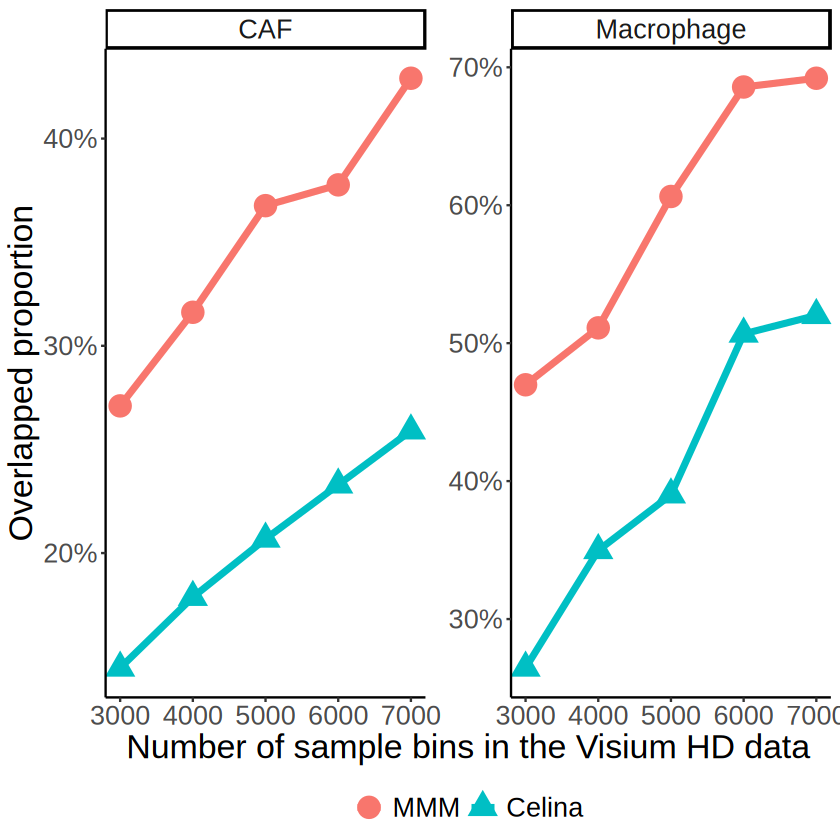

In [7]:
p <- ggplot(data = overlapped_svgs_comparison, aes(x = sample_size, y = proportion, group = method)) +
    geom_point(aes(color = method, shape = method), size = 6) +
    geom_line(aes(color = method), linewidth = 1.5) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    theme_classic() +
    labs(
        title = paste("Identified cell-type-specific SVGs in the Visium HD vs. Visium data"),
        x = "Number of sample bins in the Visium HD data", y = "Overlapped proportion"
    ) +
    facet_wrap(. ~ celltype, scales = "free_y") +
    theme(
        text = element_text(family = "Helvetica"),
        # plot.title = element_text(size = 20, hjust = 0.5),
        plot.title = element_blank(),
        axis.title = element_text(size = 20),
        axis.text = element_text(size = 16),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "bottom",
        panel.spacing = unit(1, "lines")
    )
ggsave(
    filename = file.path(
        RESULT_PATH, "comparison",
        paste0("comparison_MMM_Celina_overlapped_svgs", ".pdf")
    ),
    plot = p, width = 9, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH, "comparison",
        paste0("comparison_MMM_Celina_overlapped_svgs", ".png")
    ),
    plot = p, width = 9, height = 5
)
p

### Comparison beween `MCube` and `C-SIDE`

In [8]:
sample_size_seq <- c(3000L, 4000L, 5000L, 6000L, 7000L)
overlapped_svgs_comparison <- data.frame()
for (celltype in celltypes_tme) {
    mcube_pvalues_df <- data.frame(
        gene = rownames(mcube_pvalues_visium[[celltype]]),
        Visium = mcube_pvalues_visium[[celltype]]$combined_pvalue
    )
    for (sample_size in sample_size_seq) {
        mcube_pvalues_visiumhd <- readRDS(
            file = file.path(
                RESULT_PATH, "comparison",
                paste0("mcube_pvalues_visiumhd_", celltype, "_", sample_size, ".rds")
            )
        )[[celltype]]
        mcube_pvalues_df <- merge(
            mcube_pvalues_df,
            data.frame(
                gene = rownames(mcube_pvalues_visiumhd),
                pvalue = mcube_pvalues_visiumhd$combined_pvalue
            ),
            by = "gene"
        )
        colnames(mcube_pvalues_df)[ncol(mcube_pvalues_df)] <- paste0("Visium HD ", sample_size)
    }

    cside_pvalues_df <- data.frame(
        gene = rownames(cside_pvalues_visium[[celltype]]),
        Visium = cside_pvalues_visium[[celltype]]$p_val
    )
    for (sample_size in sample_size_seq) {
        cside_pvalues_visiumhd <- readRDS(
            file = file.path(
                RESULT_PATH, "comparison",
                paste0("cside_pvalues_visiumhd_", celltype, "_", sample_size, ".rds")
            )
        )[[celltype]]
        cside_pvalues_df <- merge(
            cside_pvalues_df,
            data.frame(
                gene = rownames(cside_pvalues_visiumhd),
                pvalue = cside_pvalues_visiumhd$p_val
            ),
            by = "gene"
        )
        colnames(cside_pvalues_df)[ncol(cside_pvalues_df)] <- paste0("Visium HD ", sample_size)
    }

    overlapped_genes <- intersect(mcube_pvalues_df$gene, cside_pvalues_df$gene)
    message(celltype, ", overlapped genes: ", length(overlapped_genes))

    mcube_pvalues_df <- mcube_pvalues_df[
        mcube_pvalues_df$gene %in% overlapped_genes,
    ]
    cside_pvalues_df <- cside_pvalues_df[
        cside_pvalues_df$gene %in% overlapped_genes,
    ]

    mcube_svgs_list <- lapply(
        mcube_pvalues_df[, -1],
        FUN = function(x) {
            x <- p.adjust(x, method = "BH")
            mcube_pvalues_df$gene[x < 0.05]
        }
    )
    names(mcube_svgs_list) <- c(
        "Visium", paste0("Visium HD ", sample_size_seq)
    )
    message(celltype, ", MCube, ", length(mcube_svgs_list$Visium))

    mcube_overlapped_svgs <- sapply(
        mcube_svgs_list,
        FUN = function(x) {
            length(intersect(x, mcube_svgs_list[["Visium"]]))
        },
        simplify = TRUE
    )
    mcube_overlapped_svgs <- data.frame(
        sample_size = sample_size_seq,
        proportion = mcube_overlapped_svgs[-1] / mcube_overlapped_svgs[1]
    )

    cside_svgs_list <- lapply(
        cside_pvalues_df[, -1],
        FUN = function(x) {
            x <- p.adjust(x, method = "BH")
            cside_pvalues_df$gene[x < 0.05]
        }
    )
    names(cside_svgs_list) <- c(
        "Visium", paste0("Visium HD ", sample_size_seq)
    )
    message(celltype, ", C-SIDE, ", length(cside_svgs_list$Visium))

    cside_overlapped_svgs <- sapply(
        cside_svgs_list,
        FUN = function(x) {
            length(intersect(x, cside_svgs_list[["Visium"]]))
        },
        simplify = TRUE
    )
    cside_overlapped_svgs <- data.frame(
        sample_size = sample_size_seq,
        proportion = cside_overlapped_svgs[-1] / cside_overlapped_svgs[1]
    )

    message(
        celltype, ", Visium, ", "SVGs identified by both methods, ",
        length(intersect(
            mcube_svgs_list[["Visium"]], celina_svgs_list[["Visium"]]
        ))
    )

    overlapped_svgs_comparison <- rbind(
        overlapped_svgs_comparison,
        data.frame(
            mcube_overlapped_svgs,
            method = "MMM",
            celltype = celltype
        ),
        data.frame(
            cside_overlapped_svgs,
            method = "C-SIDE",
            celltype = celltype
        )
    )
}
overlapped_svgs_comparison$method <- factor(
    overlapped_svgs_comparison$method,
    levels = c("MMM", "C-SIDE")
)
head(overlapped_svgs_comparison)

CAF, overlapped genes: 888

CAF, MCube, 601

CAF, C-SIDE, 214

CAF, Visium, SVGs identified by both methods, 40

Macrophage, overlapped genes: 997

Macrophage, MCube, 329

Macrophage, C-SIDE, 305

Macrophage, Visium, SVGs identified by both methods, 129



,sample_size,proportion,method,celltype
,<int>,<dbl>,<fct>,<chr>
Visium HD 3000,3000,0.3227953,MMM,CAF
Visium HD 4000,4000,0.3643927,MMM,CAF
Visium HD 5000,5000,0.4159734,MMM,CAF
Visium HD 6000,6000,0.4509151,MMM,CAF
Visium HD 7000,7000,0.4941764,MMM,CAF
Visium HD 30001,3000,0.1635514,C-SIDE,CAF


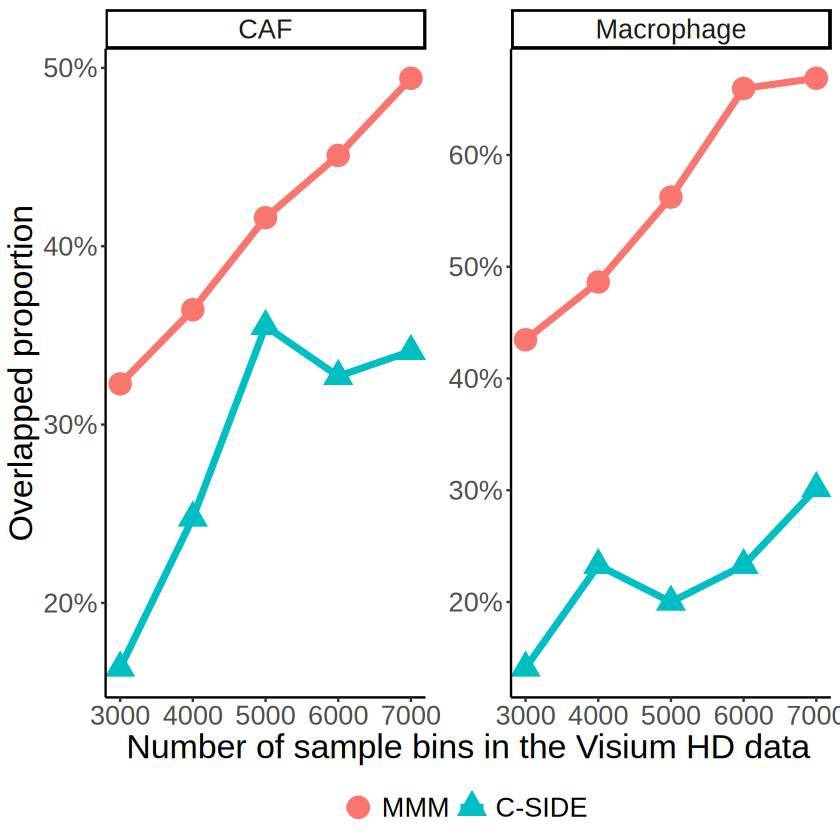

In [10]:
p <- ggplot(data = overlapped_svgs_comparison, aes(x = sample_size, y = proportion, group = method)) +
    geom_point(aes(color = method, shape = method), size = 6) +
    geom_line(aes(color = method), linewidth = 1.5) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    theme_classic() +
    labs(
        title = paste("Identified cell-type-specific SVGs in the Visium HD vs. Visium data"),
        x = "Number of sample bins in the Visium HD data", y = "Overlapped proportion"
    ) +
    facet_wrap(. ~ celltype, scales = "free") +
    theme(
        text = element_text(family = "Helvetica"),
        plot.title = element_blank(),
        axis.title = element_text(size = 20),
        axis.text = element_text(size = 16),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "bottom",
        panel.spacing = unit(1, "lines")
    )
ggsave(
    filename = file.path(
        RESULT_PATH, "comparison",
        paste0("comparison_MMM_CSIDE_overlapped_svgs", ".pdf")
    ),
    plot = p, width = 9, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH, "comparison",
        paste0("comparison_MMM_CSIDE_overlapped_svgs", ".png")
    ),
    plot = p, width = 9, height = 5
)
p